# Iceberg simulations

In [1]:
# Import of packages (utils.py) and additional functions (utils.py, simu_late.py)
from src.utils import *
from src.simu_late import *
#import importlib
#import my_package

In [2]:
# Model configurations:
dict_in = {'config':{'seed:wind_form_drag_coef':1.5, 'seed:wind_form_drag_coef':1.5}}

# Input data
dict_in['input']=['cmems_mod_arc_phy_anfc_6km_detided_PT1H-i',]

# Initial information
n=1
randspace=np.random.rand(n)
lengths, widths, sails, drafts = 81, 72, 2.9914802407484546, 21.199466273020537 #lengths, widths = randspace*(87-75)+75, randspace**(80-65)+65
lat, lon = 80.5794, 37.81915 
dict_in['seed']= {'lon': lon, 'lat': lat,
            'length': lengths, 'width': widths, 
            'sail': sails, 'draft': drafts, 
            'number': n, 'radius': 100,
           'time': datetime(2023,9,10,12,36)}
dict_in['more']={'duration':2}

o1,o1_dataset = simu_late(dict_in) #o1 can be used to create plots. o1_dataset gives back an xr.dataset

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 32.77it/s]
INFO - 2026-04-21T14:56:31Z - Selected dataset version: "202311"
INFO - 2026-04-21T14:56:31Z - Selected dataset part: "default"


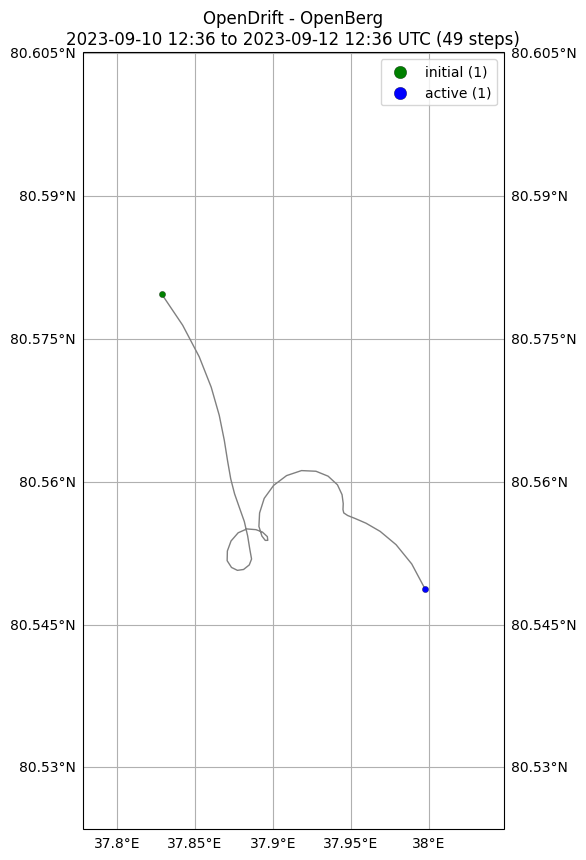

(<GeoAxes: title={'center': 'OpenDrift - OpenBerg\n2023-09-10 12:36 to 2023-09-12 12:36 UTC (49 steps)'}>,
 <Figure size 596.678x1100 with 1 Axes>)

In [5]:
# ANALYSIS
o1.plot(fast=True)

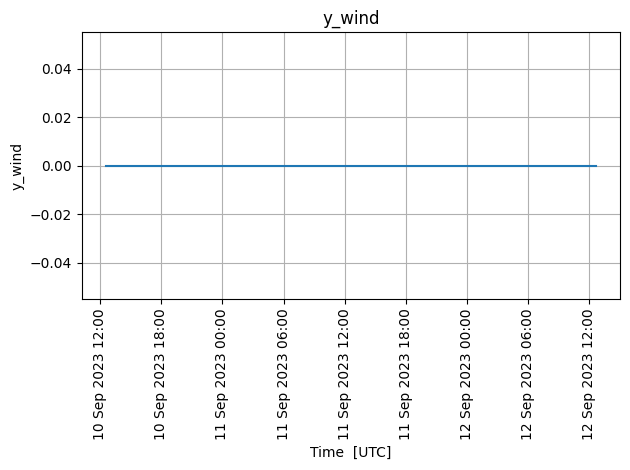

In [8]:
o1.plot_property('y_wind')

In [ ]:
#o.animation(fast=True,filename='./simulation.gif',background=['sea_water_temperature','sea_water_temperature'],show_trajectories=True)#,color='z', buffer=.1
#Image(url='./simulation.gif')



REMAINING PROBLEMS:
- does not save netcdf -> sttrb dtype error (but bin works)


In [ ]:
#SAVE TO NETCDF -> still has sttr dtype error
#ds=o1
#for k, v in ds.attrs.items():
#    if isinstance(v, np.generic):  # catches numpy scalars like np.int32, np.float64
#        ds.attrs[k] = v.item()     # convert to native Python type
#    elif isinstance(v, type) and issubclass(v, np.generic):
#        # handles cases like: np.int32 (the type itself)
#        ds.attrs[k] = v.__name__   # convert to string like "int32"
#    print(k, type(ds.attrs[k]))
#ds.to_netcdf("./results.nc") #not sure why not work no dri or file

#SAVE TO BINARY, #WORKS!
#import pickle 
#pickle.dump(o1,open("../results/results.bin",'wb'))